# Day 19: 统计基础 —— 描述统计、分布、中心极限定理

> **目标**: 掌握数据岗必备的统计概念，理解「用样本推断总体」的统计思维。
> **前置**: Day 11 的 NumPy 基础（统计函数）
> **工具**: NumPy + Pandas + Matplotlib/Seaborn
> **数据**: `../data/sales.csv` + 模拟数据

## 1. 描述统计 —— 数据的第一印象

拿到任何数据集，先用描述统计了解它的「长相」。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv("../data/sales.csv")
totals = df["total"]

# 集中趋势
print(f"均值 (mean): {totals.mean():.2f}")
print(f"中位数 (median): {totals.median():.2f}")
print(f"众数 (mode): {totals.mode().iloc[0]:.2f}")

# 离散程度
print(f"标准差 (std): {totals.std():.2f}")
print(f"方差 (var): {totals.var():.2f}")
print(f"极差 (range): {totals.max() - totals.min():.2f}")
print(f"四分位距 (IQR): {totals.quantile(0.75) - totals.quantile(0.25):.2f}")

# 分布形状
print(f"偏度 (skew): {totals.skew():.2f}")  # >0 右偏，<0 左偏
print(f"峰度 (kurt): {totals.kurt():.2f}")   # >0 尖峰，<0 平峰

# 分位数
print(f"25%: {totals.quantile(0.25):.2f}")
print(f"50%: {totals.quantile(0.50):.2f}")
print(f"75%: {totals.quantile(0.75):.2f}")
print(f"95%: {totals.quantile(0.95):.2f}")

均值 (mean): 2535.43
中位数 (median): 1797.00
众数 (mode): 1797.00
标准差 (std): 2426.25
方差 (var): 5886675.93
极差 (range): 9896.00
四分位距 (IQR): 3322.75
偏度 (skew): 1.34
峰度 (kurt): 1.24
25%: 599.00
50%: 1797.00
75%: 3921.75
95%: 7996.00


## 2. 可视化 —— 让数据说话

统计量只是数字，可视化才能直观看到分布。

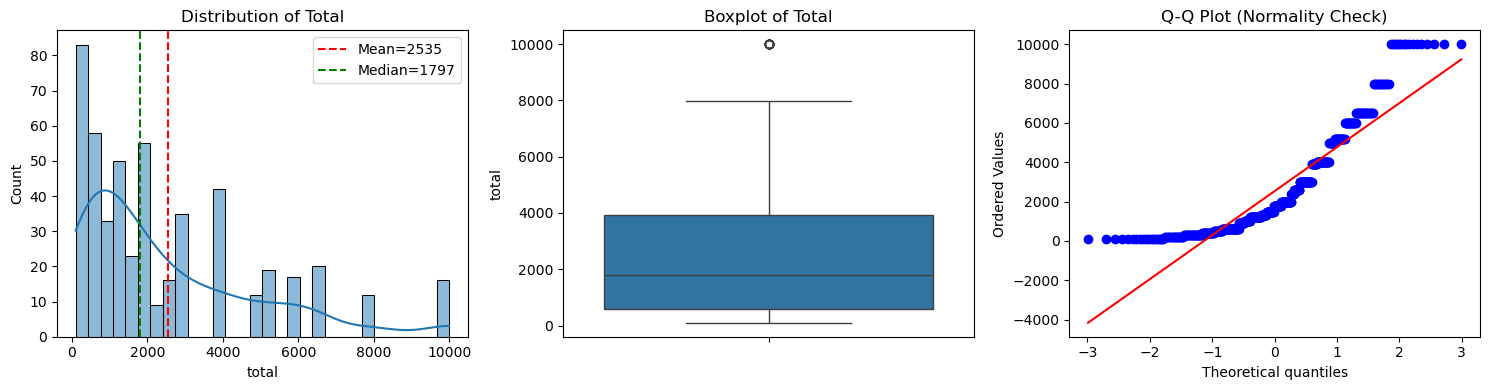

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 直方图 + KDE
sns.histplot(totals, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total")
axes[0].axvline(totals.mean(), color='red', linestyle='--', label=f'Mean={totals.mean():.0f}')
axes[0].axvline(totals.median(), color='green', linestyle='--', label=f'Median={totals.median():.0f}')
axes[0].legend()

# 箱线图
sns.boxplot(y=totals, ax=axes[1])
axes[1].set_title("Boxplot of Total")

# Q-Q 图（检验正态性）
from scipy import stats
stats.probplot(totals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normality Check)")

plt.tight_layout()
plt.show()

## 3. 正态分布 —— 统计学的基石

正态分布（高斯分布）是自然界最常见的分布。数据岗必须能判断数据是否正态。

均值: -0.05, 标准差: 0.96
在 ±1σ 内: 67.7%
在 ±2σ 内: 95.3%
在 ±3σ 内: 99.7%


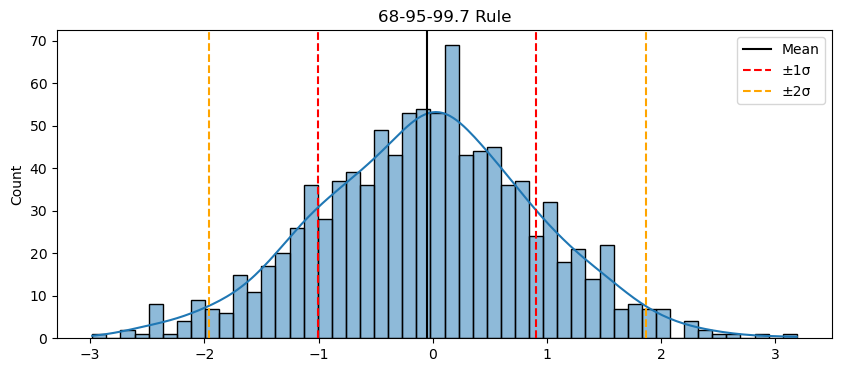

In [3]:
# 生成标准正态分布数据
normal = np.random.normal(loc=0, scale=1, size=1000)

# 68-95-99.7 法则（经验法则）
mean, std = normal.mean(), normal.std()
print(f"均值: {mean:.2f}, 标准差: {std:.2f}")
print(f"在 ±1σ 内: {((normal > mean-std) & (normal < mean+std)).mean():.1%}")
print(f"在 ±2σ 内: {((normal > mean-2*std) & (normal < mean+2*std)).mean():.1%}")
print(f"在 ±3σ 内: {((normal > mean-3*std) & (normal < mean+3*std)).mean():.1%}")

# 可视化 68-95-99.7
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(normal, bins=50, kde=True, ax=ax)
ax.axvline(mean, color='black', label='Mean')
ax.axvline(mean-std, color='red', linestyle='--', label='±1σ')
ax.axvline(mean+std, color='red', linestyle='--')
ax.axvline(mean-2*std, color='orange', linestyle='--', label='±2σ')
ax.axvline(mean+2*std, color='orange', linestyle='--')
ax.legend()
ax.set_title("68-95-99.7 Rule")
plt.show()

## 4. 中心极限定理 (CLT) —— 为什么样本均值能推断总体

**核心定理**: 无论总体是什么分布，当样本量 n ≥ 30 时，样本均值的分布**近似正态**。

这是数据岗用样本推断总体的理论基础。

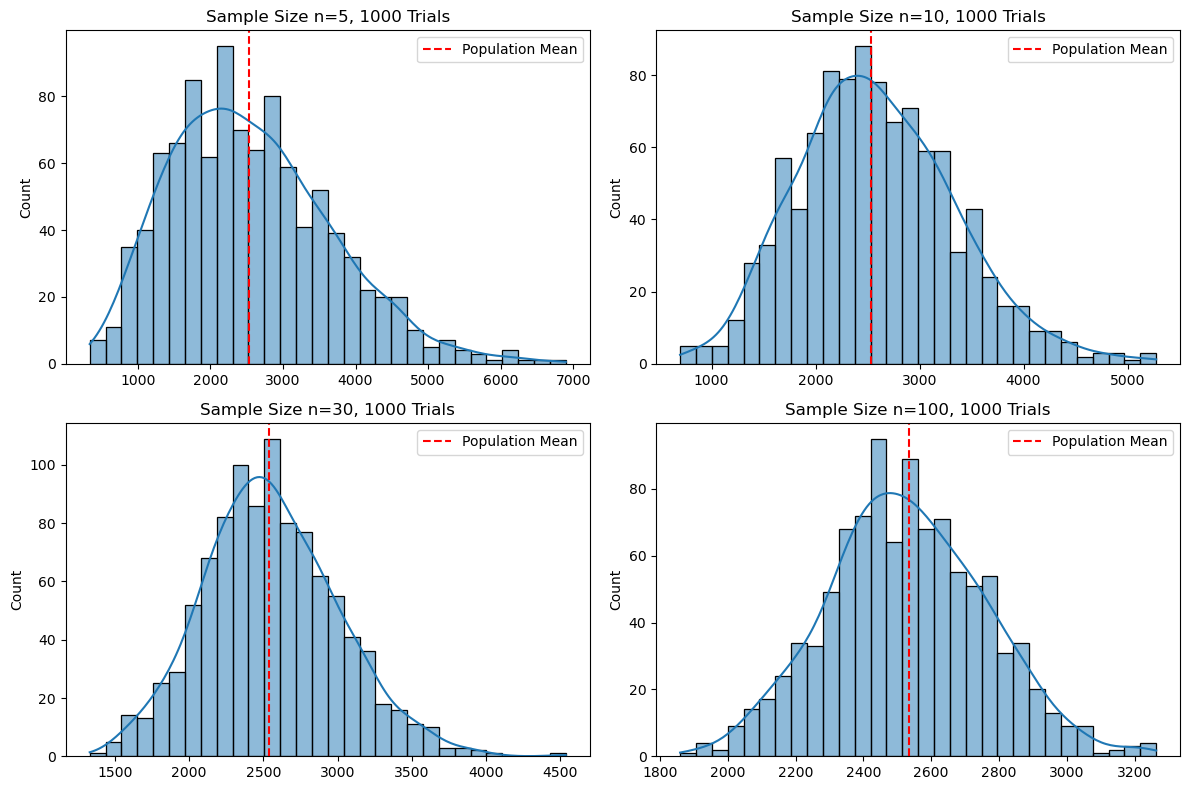

观察: n=5 时偏态明显, n=30 时接近正态, n=100 时几乎完美正态
这就是中心极限定理: 样本量越大, 样本均值分布越正态


In [4]:
# 从 sales.csv 的 total 列中反复抽样，观察样本均值的分布
np.random.seed(42)
population = df["total"].values

sample_sizes = [5, 10, 30, 100]
n_trials = 1000

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    sample_means = [np.random.choice(population, size=n, replace=True).mean() for _ in range(n_trials)]
    
    sns.histplot(sample_means, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Sample Size n={n}, {n_trials} Trials")
    axes[i].axvline(np.mean(population), color='red', linestyle='--', label='Population Mean')
    axes[i].legend()

plt.tight_layout()
plt.show()

print("观察: n=5 时偏态明显, n=30 时接近正态, n=100 时几乎完美正态")
print("这就是中心极限定理: 样本量越大, 样本均值分布越正态")

## 5. 标准误与置信区间

标准误 (Standard Error) = 标准差 / √n，衡量样本均值的精度。
置信区间 = 样本均值 ± z × 标准误，表示总体均值有 95% 概率落在这个区间。

In [5]:
# 计算 sales 数据的 95% 置信区间
sample = df["total"].sample(100, random_state=42)
mean = sample.mean()
se = sample.std() / np.sqrt(len(sample))
z = 1.96  # 95% 置信水平对应的 z 值

ci_lower = mean - z * se
ci_upper = mean + z * se

print(f"样本均值: {mean:.2f}")
print(f"标准误 (SE): {se:.2f}")
print(f"95% 置信区间: [{ci_lower:.2f}, {ci_upper:.2f}]")

# 验证: 总体均值是否落在 CI 内
pop_mean = df["total"].mean()
print(f"总体均值: {pop_mean:.2f}")
print(f"总体均值在 CI 内? {ci_lower <= pop_mean <= ci_upper}")

样本均值: 2646.14
标准误 (SE): 270.01
95% 置信区间: [2116.92, 3175.36]
总体均值: 2535.43
总体均值在 CI 内? True


## 今日要点总结

| 概念 | 公式/代码 | 含义 |
|------|-----------|------|
| 均值 | `np.mean(x)` | 平均值 |
| 中位数 | `np.median(x)` | 中间值，抗极端值 |
| 标准差 | `np.std(x)` | 数据离散程度 |
| 方差 | `np.var(x)` | 标准差的平方 |
| 偏度 | `df['x'].skew()` | >0 右偏，<0 左偏 |
| 峰度 | `df['x'].kurt()` | >0 尖峰，<0 平峰 |
| 68-95-99.7 | ±1σ, ±2σ, ±3σ | 正态分布的经验法则 |
| 标准误 | SE = σ/√n | 样本均值精度 |
| 置信区间 | mean ± z×SE | 总体均值估计范围 |
| CLT | n≥30 时，样本均值分布近似正态 | 推断统计的基石 |

**核心心法**: 描述统计回答「数据长什么样」，CLT 回答「为什么能用样本推断总体」。数据岗做分析前，先用描述统计和可视化了解数据分布。